# Daily Sales Forecasting

This notebook builds a machine learning forecasting pipeline using daily e-commerce sales data from the MySQL warehouse.

The workflow includes:
- Extracting sales data from MySQL
- Creating forecasting features
- Training a regression model
- Evaluating forecasting performance
- Predicting future sales trends

In [50]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Connect to the MySQL Data Warehouse

Creating a connection between Python and the local MySQL warehouse.

In [51]:
# MySQL database connection configuration

load_dotenv(dotenv_path="D:\Projects\supply-chain-analytics-pipeline\.env")  #load .env file

user     = os.getenv("DB_USER")
password = quote_plus(os.getenv("DB_PASSWORD"))
host     = os.getenv("DB_HOST")
port     = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

# Create engine
engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")

## Load Forecasting Dataset

Extracting business and operational metrics from the fact table for revenue forecasting.

In [61]:
query = """
SELECT
    order_date,

    SUM(total_order_value) AS daily_sales,

    COUNT(order_id) AS total_orders,

    AVG(delivery_delay_days) AS avg_delay,

    AVG(review_score) AS avg_review_score,

    SUM(is_late) AS late_orders,

    AVG(lead_time_days) AS avg_lead_time

FROM fact_orders

WHERE purchase_year >= 2017

GROUP BY order_date

ORDER BY order_date
"""

forecast_df = pd.read_sql(query, engine)

forecast_df.head()

,order_date,daily_sales,total_orders,avg_delay,avg_review_score,late_orders,avg_lead_time
0,2017-01-05,707.27,32,-25.00,4.9063,0.0,10.8125
1,2017-01-06,988.28,4,-33.75,4.7500,0.0,7.7500
2,2017-01-07,1447.99,5,-18.00,2.6000,1.0,23.0000
3,2017-01-08,809.63,6,-31.50,3.3333,0.0,8.2500
4,2017-01-09,774.51,6,-12.00,3.0000,3.0,27.3333


## Preview Forecasting Data

Checking the prepared forecasting dataset before model training.

In [62]:
forecast_df.shape

(603, 7)

In [63]:
forecast_df.describe()

,daily_sales,total_orders,avg_delay,avg_review_score,late_orders,avg_lead_time
count,603.000000,603.000000,602.000000,603.000000,603.000000,602.000000
mean,26299.350398,187.296849,-13.237453,4.051211,14.510779,12.361523
std,14569.202808,105.116640,5.111814,0.268875,21.594984,2.942187
min,166.460000,1.000000,-36.285700,1.000000,0.000000,1.000000
25%,15913.910000,117.000000,-14.730400,3.941700,3.000000,10.725975
50%,24083.230000,172.000000,-12.623000,4.088700,7.000000,12.073750
75%,34743.620000,251.000000,-10.352000,4.203900,16.000000,14.023800
max,180377.790000,1380.000000,-3.150800,4.906300,260.000000,27.333300


In [64]:
forecast_df.isnull().sum()

order_date          0
daily_sales         0
total_orders        0
avg_delay           1
avg_review_score    0
late_orders         0
avg_lead_time       1
dtype: int64

## Remove Incomplete Rows

Dropping rows with missing operational metrics so the model can train properly.

In [65]:
forecast_df = forecast_df.dropna().reset_index(drop=True)
forecast_df.isnull().sum()

order_date          0
daily_sales         0
total_orders        0
avg_delay           0
avg_review_score    0
late_orders         0
avg_lead_time       0
dtype: int64

## Create Forecasting Features

Creating time-based features to help the model learn sales behavior.

Features:
- Previous day sales
- 7-day rolling average
- Day of week
- Month

In [66]:
forecast_df['order_date'] = pd.to_datetime(forecast_df['order_date'])

forecast_df['lag_1_sales'] = forecast_df['daily_sales'].shift(1)
forecast_df['rolling_7_sales'] = forecast_df['daily_sales'].rolling(window=7).mean()
forecast_df['day_of_week'] = forecast_df['order_date'].dt.dayofweek
forecast_df['month'] = forecast_df['order_date'].dt.month

## Final Clean-Up After Feature Creation

Dropping rows created by lag and rolling calculations.

In [67]:
forecast_df.isnull().sum()

order_date          0
daily_sales         0
total_orders        0
avg_delay           0
avg_review_score    0
late_orders         0
avg_lead_time       0
lag_1_sales         1
rolling_7_sales     6
day_of_week         0
month               0
dtype: int64

In [73]:
forecast_df = forecast_df.dropna().reset_index(drop=True)
forecast_df.head(10)

,order_date,daily_sales,total_orders,avg_delay,avg_review_score,late_orders,avg_lead_time,lag_1_sales,rolling_7_sales,day_of_week,month
0,2017-01-11,3062.33,12,-31.6000,3.8333,0.0,7.4000,1571.17,1337.311429,2,1
1,2017-01-12,2502.69,15,-18.1429,3.7333,2.0,24.2143,3062.33,1593.800000,3,1
2,2017-01-13,2780.72,11,-30.9000,4.3000,0.0,9.6000,2502.69,1849.862857,4,1
3,2017-01-14,1499.57,18,-23.1875,3.5882,1.0,15.4375,2780.72,1857.231429,5,1
4,2017-01-15,2720.57,22,-33.8182,4.1818,0.0,12.1364,1499.57,2130.222857,6,1
5,2017-01-16,3708.40,24,-27.3043,4.2273,0.0,12.7826,2720.57,2549.350000,0,1
6,2017-01-17,3979.73,38,-30.1316,4.2895,0.0,11.1053,3708.40,2893.430000,1,1
7,2017-01-18,4683.38,35,-27.7813,3.8125,1.0,12.9375,3979.73,3125.008571,2,1
8,2017-01-19,4140.16,35,-27.8286,4.2000,1.0,11.4000,4683.38,3358.932857,3,1
9,2017-01-20,4656.05,39,-27.2051,4.4615,0.0,13.0256,4140.16,3626.837143,4,1


In [74]:
forecast_df.shape

(596, 11)

## Prepare Features and Target Variable

Separating input features and target variable for model training.

In [75]:
X = forecast_df[
    [
        'total_orders',
        'avg_delay',
        'avg_review_score',
        'late_orders',
        'avg_lead_time',
        'lag_1_sales',
        'rolling_7_sales',
        'day_of_week',
        'month'
    ]
]

y = forecast_df['daily_sales']

## Split Data into Training and Testing Sets

Using the first 80% of the timeline for training and the last 20% for testing.

In [76]:
split_index = int(len(forecast_df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))

Training Rows: 476
Testing Rows: 120


## Train the Linear Regression Model

Training the forecasting model using historical business data.

In [77]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Generate Revenue Predictions

Predicting future revenue values using the trained model.

In [79]:
y_pred = model.predict(X_test)

predictions_df = pd.DataFrame({
    'actual_revenue': y_test.values,
    'predicted_revenue': y_pred
})

predictions_df.head()

,actual_revenue,predicted_revenue
0,44826.19,46572.953848
1,49575.72,48525.817670
2,45494.10,42142.254537
3,32608.15,30723.024780
4,32994.23,33398.547833


## Evaluate Model Performance

Measuring forecast accuracy using MAE, RMSE, and R² Score.

In [80]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

MAE: 3269.5
RMSE: 4301.55
R2 Score: 0.887


## Visualize Actual vs Predicted Sales

Comparing model predictions with actual sales values.

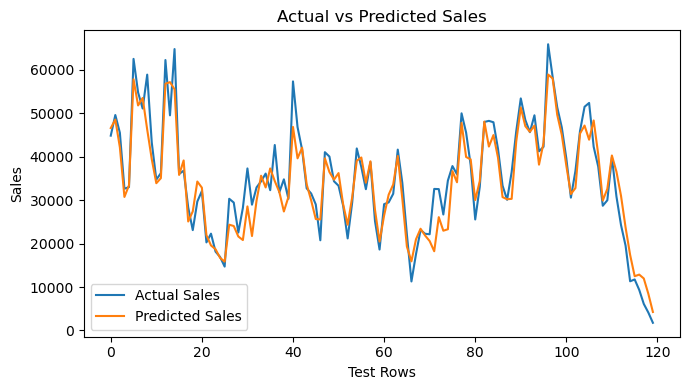

In [90]:
plt.figure(figsize=(7, 4))
plt.plot(predictions_df['actual_revenue'].values, label='Actual Sales')
plt.plot(predictions_df['predicted_revenue'].values, label='Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Test Rows')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

## Forecast Future Sales

Predicting sales for the next 30 days using the trained model.

In [93]:
future_days = 30

last_date = forecast_df['order_date'].max()
last_day_num = len(forecast_df)

last_lag = forecast_df['daily_sales'].iloc[-1]
last_rolling = forecast_df['daily_sales'].tail(7).mean()
last_orders = int(forecast_df['total_orders'].mean())
last_delay = forecast_df['avg_delay'].mean()
last_review = forecast_df['avg_review_score'].mean()
last_late = int(forecast_df['late_orders'].mean())
last_lead = forecast_df['avg_lead_time'].mean()

future_rows = []

for i in range(1, future_days + 1):
    future_date = last_date + pd.Timedelta(days=i)
    future_rows.append({
        'total_orders': last_orders,
        'avg_delay': last_delay,
        'avg_review_score': last_review,
        'late_orders': last_late,
        'avg_lead_time': last_lead,
        'lag_1_sales': last_lag,
        'rolling_7_sales': last_rolling,
        'day_of_week': future_date.dayofweek,
        'month': future_date.month,
        'order_date': future_date
    })

future_df = pd.DataFrame(future_rows)

future_X = future_df[
    [
        'total_orders',
        'avg_delay',
        'avg_review_score',
        'late_orders',
        'avg_lead_time',
        'lag_1_sales',
        'rolling_7_sales',
        'day_of_week',
        'month'
    ]
]

future_df['predicted_sales'] = model.predict(future_X)
future_df[['order_date', 'predicted_sales']].head(10)

,order_date,predicted_sales
0,2018-08-30,25390.920748
1,2018-08-31,25267.345045
2,2018-09-01,25137.124945
3,2018-09-02,25013.549242
4,2018-09-03,25755.003456
5,2018-09-04,25631.427754
6,2018-09-05,25507.852052
7,2018-09-06,25384.276349
8,2018-09-07,25260.700647
9,2018-09-08,25137.124945


## Save Forecast Results to MySQL

Storing predicted sales values in a MySQL table for Power BI reporting.

In [95]:
forecast_output = future_df[['order_date', 'predicted_sales']].copy()
forecast_output.rename(columns={'order_date': 'forecast_date'}, inplace=True)

forecast_output.to_sql(
    'sales_forecast',
    con=engine,
    if_exists='replace',
    index=False
)

print("Forecast table saved to MySQL successfully.")

Forecast table saved to MySQL successfully.


## Preview Forecast Output

Checking the final forecast table.

In [96]:
forecast_output.head(10)

,forecast_date,predicted_sales
0,2018-08-30,25390.920748
1,2018-08-31,25267.345045
2,2018-09-01,25137.124945
3,2018-09-02,25013.549242
4,2018-09-03,25755.003456
5,2018-09-04,25631.427754
6,2018-09-05,25507.852052
7,2018-09-06,25384.276349
8,2018-09-07,25260.700647
9,2018-09-08,25137.124945
